# Notebook 4 — Exploratory Data Analysis

## Objective

Perform detailed exploratory data analysis using the training split only.

The analysis will investigate:

- Data types, shape, and memory usage
- Missing values
- Numerical variables
- Categorical variables
- Relationships between features and the target label
- Date and time patterns
- Geography
- Potential outliers and invalid values

The goal is to identify useful features, understand the data quality,
and inform later feature engineering and model selection.

## Important

Only the training dataset is used in this notebook.
Validation and test data are not opened or analyzed.

## Artifact

- Saved EDA charts
- Short findings summary

# Load TRAIN only

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

train = pd.read_parquet("../artifacts/train.parquet")

print("Train shape:", train.shape)
display(train.head())

Train shape: (67533, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,item_count,product_count,seller_count,total_price,total_freight,payment_count,payment_value,max_installments,label
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,sao joaquim da barra,SP,3.0,1.0,1.0,134.97,8.49,NaN,NaN,NaN,Late
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,sao paulo,SP,1.0,1.0,1.0,29.90,15.56,1.0,45.46,1.0,On Time
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,panambi,RS,1.0,1.0,1.0,21.90,17.19,1.0,39.09,1.0,On Time
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,b8b8726af116a5cfb35b0315ecef9172,rio de janeiro,RJ,1.0,1.0,1.0,21.50,14.11,1.0,35.61,1.0,On Time
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,porto alegre,RS,1.0,1.0,1.0,36.49,17.24,1.0,53.73,1.0,On Time


# Basic structure

In [72]:
print("Shape:", train.shape)

print("\nData types:")
display(train.dtypes)

Shape: (67533, 20)

Data types:


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_city                               str
customer_state                              str
item_count                              float64
product_count                           float64
seller_count                            float64
total_price                             float64
total_freight                           float64
payment_count                           float64
payment_value                           float64
max_installments                        float64
label                                       str
dtype: object

In [73]:
memory_mb = train.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Memory usage: {memory_mb:.2f} MB")

Memory usage: 20.76 MB


# Class distribution

In [74]:
label_counts = train["label"].value_counts()

display(label_counts)

label
On Time    61436
Late        6097
Name: count, dtype: int64

In [75]:
display(
    train["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
On Time    90.97
Late        9.03
Name: proportion, dtype: float64

# Identify column types

In [76]:
for column in train.columns:
    print(f"{column:45} {train[column].dtype}")

order_id                                      str
customer_id                                   str
order_status                                  str
order_purchase_timestamp                      datetime64[us]
order_approved_at                             str
order_delivered_carrier_date                  str
order_delivered_customer_date                 datetime64[us]
order_estimated_delivery_date                 datetime64[us]
customer_unique_id                            str
customer_city                                 str
customer_state                                str
item_count                                    float64
product_count                                 float64
seller_count                                  float64
total_price                                   float64
total_freight                                 float64
payment_count                                 float64
payment_value                                 float64
max_installments                       

In [77]:
id_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

In [78]:
numeric_columns = train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric:", numeric_columns)
print("Categorical:", categorical_columns)
print("Date:", date_columns)
print("ID:", id_columns)

Numeric: ['item_count', 'product_count', 'seller_count', 'total_price', 'total_freight', 'payment_count', 'payment_value', 'max_installments']
Categorical: ['order_id', 'customer_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'customer_unique_id', 'customer_city', 'customer_state', 'label']
Date: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
ID: ['order_id', 'customer_id', 'customer_unique_id']


/var/folders/2h/y4vj7yz97fs8_0qght7rjn_h0000gn/T/ipykernel_53472/3438405590.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train.select_dtypes(


# Missing values

In [79]:
missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct.round(2)
})

display(
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
)

,missing_count,missing_percent
order_approved_at,14,0.02
max_installments,1,0.00
payment_value,1,0.00
order_delivered_carrier_date,1,0.00
payment_count,1,0.00


In [80]:
for column in missing_summary[
    missing_summary["missing_count"] > 0
].index:
    
    print("\n", column)
    print(train.groupby(
        train[column].isna()
    )["label"].value_counts(normalize=True))


 order_approved_at
order_approved_at  label  
False              On Time    0.909699
                   Late       0.090301
True               On Time    1.000000
Name: proportion, dtype: float64

 max_installments
max_installments  label  
False             On Time    0.909732
                  Late       0.090268
True              Late       1.000000
Name: proportion, dtype: float64

 payment_value
payment_value  label  
False          On Time    0.909732
               Late       0.090268
True           Late       1.000000
Name: proportion, dtype: float64

 order_delivered_carrier_date
order_delivered_carrier_date  label  
False                         On Time    0.909732
                              Late       0.090268
True                          Late       1.000000
Name: proportion, dtype: float64

 payment_count
payment_count  label  
False          On Time    0.909732
               Late       0.090268
True           Late       1.000000
Name: proportion, dtype: float64


# Numerical variables

In [81]:
display(
    train[numeric_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
item_count,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.000,21.00
product_count,67533.0,1.037715,0.222223,1.00,1.00,1.00,1.000,7.00
seller_count,67533.0,1.012053,0.114812,1.00,1.00,1.00,1.000,5.00
total_price,67533.0,135.884499,205.187627,2.29,45.90,85.00,149.900,13440.00
total_freight,67533.0,22.244256,19.999582,0.00,14.10,16.79,23.700,1002.29
payment_count,67532.0,1.047622,0.397212,1.00,1.00,1.00,1.000,26.00
payment_value,67532.0,158.167657,214.277783,10.07,61.63,104.19,175.485,13664.08
max_installments,67532.0,2.974397,2.755007,1.00,1.00,2.00,4.000,24.00


In [82]:
skewness = (
    train[numeric_columns]
    .skew()
    .sort_values(ascending=False)
)

display(skewness)

payment_count       22.420165
total_price         10.719309
seller_count        10.525258
payment_value       10.149896
total_freight        8.584291
item_count           8.106935
product_count        7.675360
max_installments     1.592864
dtype: float64

# Numerical distributions

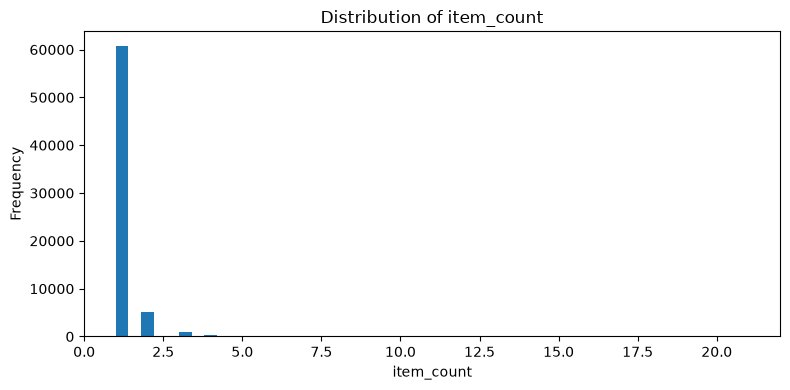

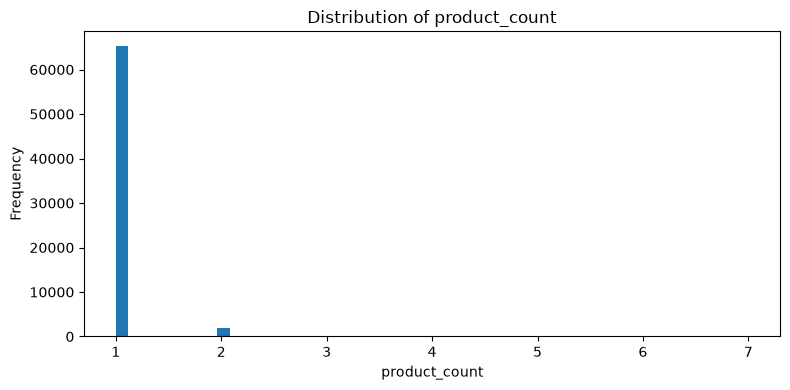

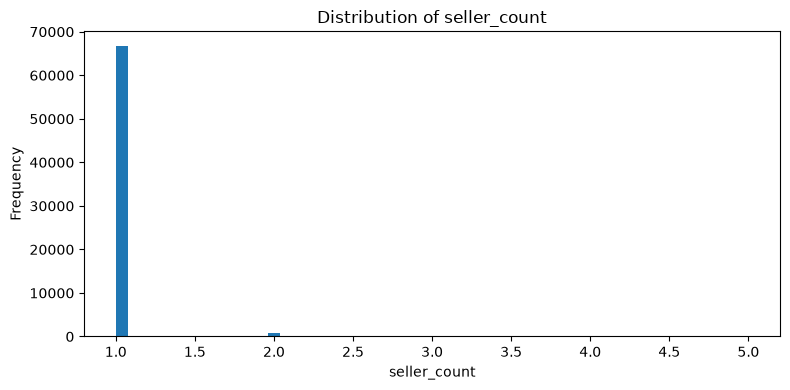

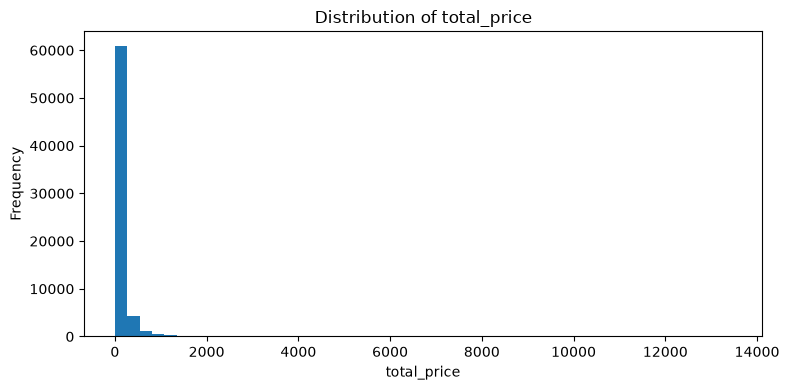

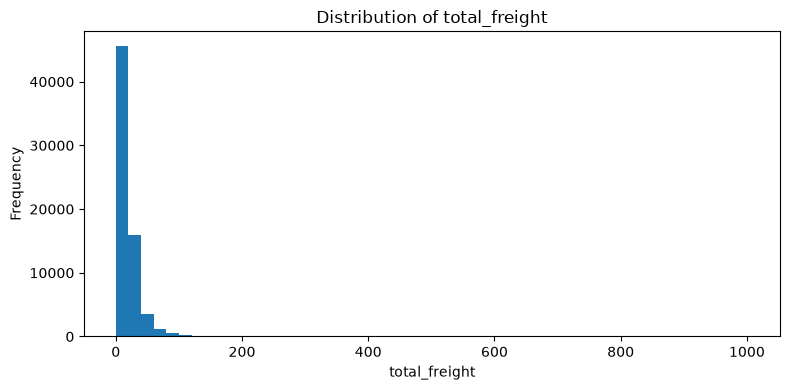

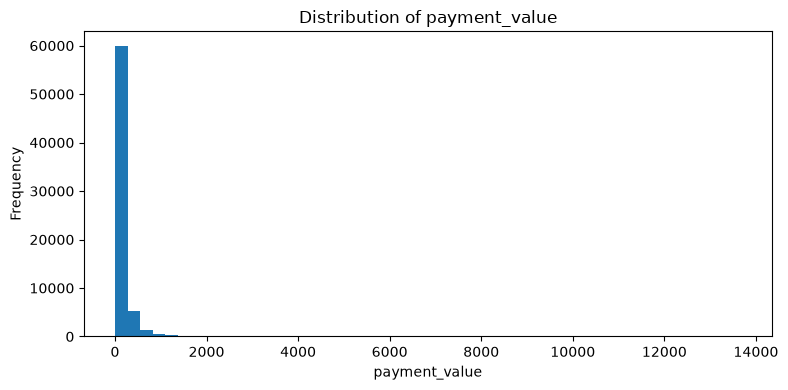

In [83]:
numeric_to_plot = [
    "item_count",
    "product_count",
    "seller_count",
    "total_price",
    "total_freight",
    "payment_value"
]

for column in numeric_to_plot:
    if column in train.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(train[column].dropna(), bins=50)
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

# Outliers and impossible values

In [84]:
for column in numeric_columns:
    print(
        column,
        "min =", train[column].min(),
        "max =", train[column].max()
    )

item_count min = 1.0 max = 21.0
product_count min = 1.0 max = 7.0
seller_count min = 1.0 max = 5.0
total_price min = 2.29 max = 13440.0
total_freight min = 0.0 max = 1002.2900000000001
payment_count min = 1.0 max = 26.0
payment_value min = 10.07 max = 13664.08
max_installments min = 1.0 max = 24.0


In [85]:
for column in [
    "item_count",
    "product_count",
    "seller_count",
    "total_price",
    "total_freight",
    "payment_value"
]:
    if column in train.columns:
        print(
            column,
            "negative values:",
            (train[column] < 0).sum()
        )

item_count negative values: 0
product_count negative values: 0
seller_count negative values: 0
total_price negative values: 0
total_freight negative values: 0
payment_value negative values: 0


# Categorical variables

In [86]:
categorical_summary = pd.DataFrame({
    "unique_values": [
        train[column].nunique()
        for column in categorical_columns
    ]
}).sort_values("unique_values", ascending=False)

display(categorical_summary)

,unique_values
0,67533
1,67533
5,65401
4,63242
3,63153
6,3747
7,27
2,2
8,2


In [87]:
for column in [
    "customer_state",
    "label"
]:
    if column in train.columns:
        print(f"\n{column}")
        display(train[column].value_counts().head(20))


customer_state


customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
MS      502
PB      370
RN      349
PI      348
AL      298
Name: count, dtype: int64


label


label
On Time    61436
Late        6097
Name: count, dtype: int64

# Categorical variables vs label

In [88]:
state_label = pd.crosstab(
    train["customer_state"],
    train["label"],
    normalize="index"
) * 100

display(
    state_label.sort_values(
        "Late",
        ascending=False
    )
)

label,Late,On Time
customer_state,,
AL,27.852349,72.147651
MA,21.532847,78.467153
CE,18.248945,81.751055
RR,17.241379,82.758621
SE,17.073171,82.926829
PI,16.666667,83.333333
RJ,16.583027,83.416973
BA,14.997833,85.002167
PA,13.370474,86.629526


# Numerical variables vs label

In [89]:
display(
    train.groupby("label")[
        [
            "item_count",
            "product_count",
            "seller_count",
            "total_price",
            "total_freight",
            "payment_value"
        ]
    ].agg(["mean", "median"])
)

item_count        product_count        seller_count         \
              mean median          mean median         mean median   
label                                                                
Late      1.114319    1.0      1.022470    1.0     1.002624    1.0   
On Time   1.144834    1.0      1.039228    1.0     1.012989    1.0   

        total_price        total_freight        payment_value           
               mean median          mean median          mean   median  
label                                                                   
Late     149.767376  89.99     25.202941  18.12    175.007633  113.855  
On Time  134.506741  84.99     21.950632  16.60    156.496706  103.050

# Correlations

In [90]:
corr = train[numeric_columns].corr()

display(corr)

,item_count,product_count,seller_count,total_price,total_freight,payment_count,payment_value,max_installments
item_count,1.000000,0.457178,0.260587,0.155733,0.475176,-0.003912,0.193599,0.065080
product_count,0.457178,1.000000,0.562566,0.056311,0.208000,0.007668,0.073438,0.068309
seller_count,0.260587,0.562566,1.000000,0.039235,0.122014,0.017610,0.049134,0.055890
total_price,0.155733,0.056311,0.039235,1.000000,0.414521,0.000037,0.996354,0.310621
total_freight,0.475176,0.208000,0.122014,0.414521,1.000000,0.000196,0.490457,0.198555
payment_count,-0.003912,0.007668,0.017610,0.000037,0.000196,1.000000,0.000039,-0.044826
payment_value,0.193599,0.073438,0.049134,0.996354,0.490457,0.000039,1.000000,0.316425
max_installments,0.065080,0.068309,0.055890,0.310621,0.198555,-0.044826,0.316425,1.000000


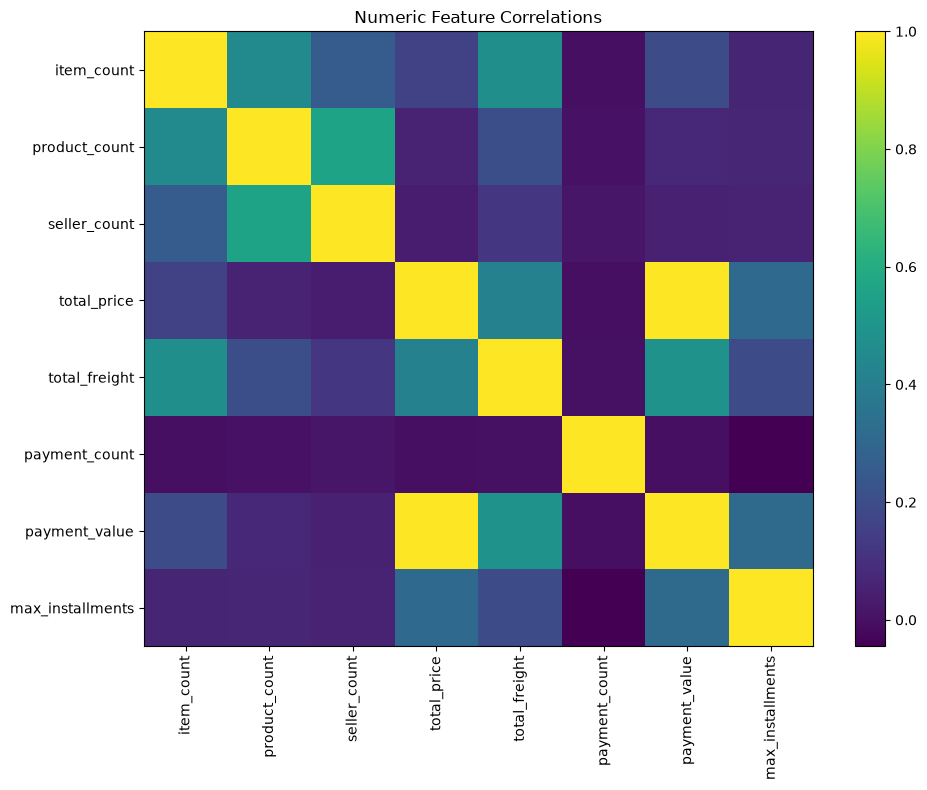

In [91]:
plt.figure(figsize=(10, 8))

plt.imshow(corr, aspect="auto")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.title("Numeric Feature Correlations")
plt.colorbar()
plt.tight_layout()
plt.show()

# Dates

In [92]:
train["purchase_date"] = train[
    "order_purchase_timestamp"
].dt.date

train["purchase_weekday"] = train[
    "order_purchase_timestamp"
].dt.day_name()

train["purchase_month"] = train[
    "order_purchase_timestamp"
].dt.month

train["purchase_year"] = train[
    "order_purchase_timestamp"
].dt.year

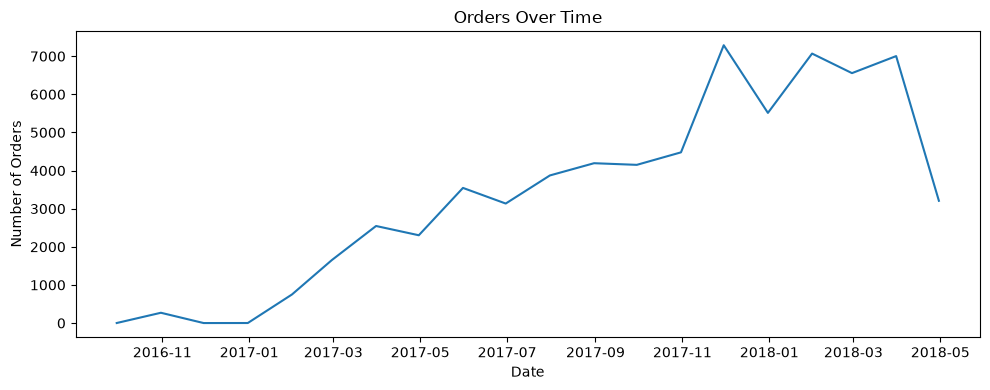

In [93]:
orders_by_month = (
    train.set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

plt.figure(figsize=(10, 4))
plt.plot(orders_by_month)
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

# Weekday effect

In [94]:
weekday_late = pd.crosstab(
    train["purchase_weekday"],
    train["label"],
    normalize="index"
) * 100

display(weekday_late)

label,Late,On Time
purchase_weekday,,
Friday,9.468892,90.531108
Monday,10.022355,89.977645
Saturday,8.967606,91.032394
Sunday,8.380837,91.619163
Thursday,8.285857,91.714143
Tuesday,9.264610,90.735390
Wednesday,8.608183,91.391817


In [95]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_late = weekday_late.reindex(weekday_order)

display(weekday_late)

label,Late,On Time
purchase_weekday,,
Monday,10.022355,89.977645
Tuesday,9.264610,90.735390
Wednesday,8.608183,91.391817
Thursday,8.285857,91.714143
Friday,9.468892,90.531108
Saturday,8.967606,91.032394
Sunday,8.380837,91.619163


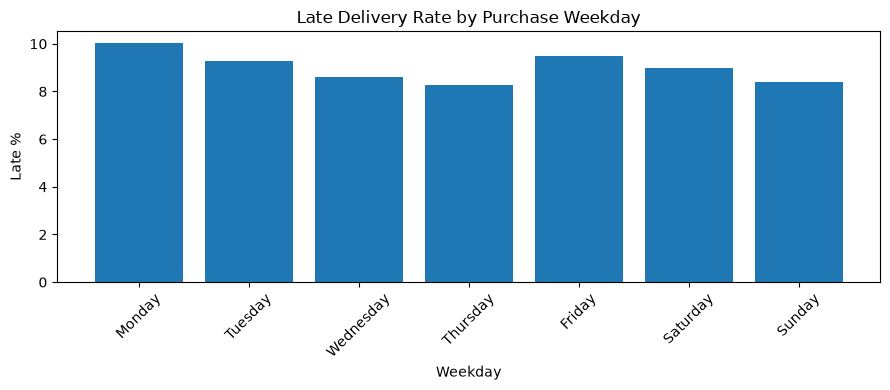

In [96]:
plt.figure(figsize=(9, 4))

plt.bar(
    weekday_late.index,
    weekday_late["Late"]
)

plt.title("Late Delivery Rate by Purchase Weekday")
plt.xlabel("Weekday")
plt.ylabel("Late %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Delivery time

In [97]:
train["delivery_days"] = (
    train["order_delivered_customer_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

In [98]:
display(
    train.groupby("label")["delivery_days"]
    .agg(["count", "mean", "median", "min", "max"])
)

,count,mean,median,min,max
label,,,,,
Late,6097,34.508173,31.271493,7.772269,209.628611
On Time,61436,11.772115,10.801806,0.533414,70.213611


# Geography

In [99]:
for column in ["customer_state", "seller_state"]:
    if column in train.columns:
        print(f"\n{column}")
        display(train[column].value_counts().head(20))


customer_state


customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
MS      502
PB      370
RN      349
PI      348
AL      298
Name: count, dtype: int64

In [100]:
for column in ["customer_state", "seller_state"]:
    if column in train.columns:
        result = pd.crosstab(
            train[column],
            train["label"],
            normalize="index"
        ) * 100

        print(f"\nLate rate by {column}")
        display(
            result.sort_values("Late", ascending=False).head(15)
        )


Late rate by customer_state


label,Late,On Time
customer_state,,
AL,27.852349,72.147651
MA,21.532847,78.467153
CE,18.248945,81.751055
RR,17.241379,82.758621
SE,17.073171,82.926829
PI,16.666667,83.333333
RJ,16.583027,83.416973
BA,14.997833,85.002167
PA,13.370474,86.629526


## Summary Findings

### 1. Dataset Structure and Target

The training dataset contains 67,533 orders. The target variable is imbalanced, with
90.97% of orders classified as On Time and 9.03% classified as Late.

This represents a substantial class imbalance, so accuracy alone should not be used to
judge model performance. Precision, recall, F1-score, and other classification metrics
should also be considered, particularly for the Late class.

### 2. Data Quality and Missing Values

No negative values were found in the main numerical variables, including `item_count`,
`product_count`, `seller_count`, `total_price`, `total_freight`, and `payment_value`.
This indicates that there are no obvious invalid negative values in these measures.

Missing values are very limited. The largest number of missing values occurs in
`order_approved_at` with only 14 records (0.02%). The remaining missing values occur in
`order_delivered_carrier_date`, `payment_count`, `payment_value`, and
`max_installments`, with only one missing value in each.

Overall, missingness is minimal and is unlikely to significantly affect the analysis.
Appropriate handling of these values should still be applied during feature engineering.

### 3. Numerical Variables and Outliers

The numerical variables are generally right-skewed, particularly `total_price`,
`payment_value`, `total_freight`, `item_count`, and `seller_count`.

Several variables contain extreme values. For example, `total_price` reaches 13,440,
`payment_value` reaches 13,664.08, and `total_freight` reaches 1,002.29. These values
should be investigated but should not automatically be removed because they may represent
legitimate large orders.

The comparison between Late and On Time orders shows some differences in numerical
variables. Late orders have higher average `total_price` (149.77 vs. 134.51),
`total_freight` (25.20 vs. 21.95), and `payment_value` (175.01 vs. 156.50).

However, the median values are relatively close, suggesting that these differences are
partly influenced by high-value orders and skewed distributions.

### 4. Correlations Between Numerical Variables

`total_price` and `payment_value` have a very strong positive correlation of approximately
0.996, indicating that these variables contain highly similar information.

There are also moderate correlations between `item_count` and `total_freight` (0.475),
`product_count` and `seller_count` (0.563), and `total_price` and `total_freight` (0.415).

The strong correlation between `total_price` and `payment_value` should be considered
during feature engineering because including both may provide redundant information.

### 5. Customer Geography

Customer state shows substantial differences in late-delivery rates.

The overall Late rate in the training dataset is 9.03%, but some states have considerably
higher rates. For example, AL has a Late rate of 27.85%, MA 21.53%, CE 18.25%, and RJ
16.58%.

In contrast, several states have considerably lower Late rates, including RO (3.78%),
AC (4.55%), AM (4.76%), PR (5.43%), and SP (5.59%).

The differences suggest that customer state may contain useful predictive information
related to delivery performance. However, states with small numbers of observations
should be interpreted cautiously.

The customer distribution is also highly concentrated in certain states. SP is the
largest group with 27,204 orders, followed by RJ with 8,967 and MG with 8,130.

### 6. Purchase Day of Week

Late-delivery rates vary somewhat by purchase weekday.

The highest Late rate occurs for Monday purchases at 10.02%, followed by Friday at 9.47%.
The lowest rate occurs on Thursday at 8.29%, followed by Sunday at 8.38%.

The differences are relatively small compared with the geographic differences, but
purchase weekday may still provide useful information when combined with other
time-related features.

### 7. Delivery Time

A clear difference exists in delivery duration between the two classes.

Late orders have an average delivery duration of approximately 34.51 days, compared with
11.77 days for On Time orders. The median delivery duration is also substantially higher
for Late orders (31.27 days vs. 10.80 days).

However, actual delivery duration must **not** be used as a predictive feature because it
depends on the actual delivery date, which is only known after the order has been
delivered. Using it would introduce target leakage.

Instead, features should be created from information available at prediction time, such
as purchase date, estimated delivery date, approval timing, and other order
characteristics.

### 8. Feature Engineering Implications

The EDA suggests several potentially useful feature groups:

- Order characteristics such as item, product, and seller counts.
- Price and freight-related features.
- Payment-related features.
- Customer state.
- Purchase weekday and other time-based features.
- Date-based durations that are available before the prediction point.

Strongly skewed numerical variables may benefit from transformations such as
logarithmic scaling.

Highly correlated variables, particularly `total_price` and `payment_value`, should be
reviewed to avoid unnecessary redundancy.

The target imbalance should also be considered during model training and evaluation.

Overall, the EDA indicates that **time-related features, customer geography, order
characteristics, and financial/order-level features** are the main areas to explore in
the next stage of feature engineering.

# Save charts

In [101]:
from pathlib import Path

CHARTS_DIR = Path("../artifacts/eda_charts")
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Charts will be saved to:", CHARTS_DIR)

Charts will be saved to: ../artifacts/eda_charts


In [102]:
plt.savefig(
    CHARTS_DIR / "orders_over_time.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>